# Seq2Seq Model 2 — T5 v1.1 Small with LoRA

This notebook presents the fine-tuning of the `google/t5-v1_1-small` sequence-to-sequence model using LoRA.

The same dataset split, training strategy, and test instruction are reused to allow a fair comparison with the other models.

In [2]:
%pip install -r requirements.txt

  Using cached fastapi-0.115.12-py3-none-any.whl.metadata (27 kB)
  Using cached pydantic-2.11.7-py3-none-any.whl.metadata (67 kB)
  Using cached uvicorn-0.35.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached starlette-0.46.2-py3-none-any.whl.metadata (6.2 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.33.2.tar.gz (435 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached fastapi-0.115.12-py3-none-any.whl (95 kB)
Using cached pydantic-2.11.7-py3-none-any.whl (44

  error: subprocess-exited-with-error
  
  × Building wheel for pydantic-core (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [57 lines of output]
      Rust not found, installing into a temporary directory
      Python reports SOABI: cp314-win_amd64
      Computed rustc target triple: x86_64-pc-windows-msvc
      Installation directory: C:\Users\analu\AppData\Local\puccinialin\puccinialin\Cache
      Rustup already downloaded
      Installing rust to C:\Users\analu\AppData\Local\puccinialin\puccinialin\Cache\rustup
      warn: It looks like you have an existing rustup settings file at:
      warn: C:\Users\analu\AppData\Local\puccinialin\puccinialin\Cache\rustup\settings.toml
      warn: Rustup will install the default toolchain as specified in the settings file,
      warn: instead of the one inferred from the default host triple.
      warn: installing msvc toolchain without its prerequisites
      info: profile set to minimal
      info: setting default host tripl

  Using cached fastapi-0.115.12-py3-none-any.whl.metadata (27 kB)
  Using cached pydantic-2.11.7-py3-none-any.whl.metadata (67 kB)
  Using cached uvicorn-0.35.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached starlette-0.46.2-py3-none-any.whl.metadata (6.2 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.33.2.tar.gz (435 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached fastapi-0.115.12-py3-none-any.whl (95 kB)
Using cached pydantic-2.11.7-py3-none-any.whl (44

  error: subprocess-exited-with-error
  
  × Building wheel for pydantic-core (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [58 lines of output]
      Rust not found, installing into a temporary directory
      Python reports SOABI: cp314-win_amd64
      Computed rustc target triple: x86_64-pc-windows-msvc
      Installation directory: C:\Users\analu\AppData\Local\puccinialin\puccinialin\Cache
      Rustup already downloaded
      Installing rust to C:\Users\analu\AppData\Local\puccinialin\puccinialin\Cache\rustup
      warn: It looks like you have an existing rustup settings file at:
      warn: C:\Users\analu\AppData\Local\puccinialin\puccinialin\Cache\rustup\settings.toml
      warn: Rustup will install the default toolchain as specified in the settings file,
      warn: instead of the one inferred from the default host triple.
      warn: installing msvc toolchain without its prerequisites
      info: profile set to minimal
      info: setting default host tripl

## 1. Import Libraries

In [ ]:
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    PeftModel
)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.12.0+cpu
CUDA available: False


## 2. Loading the Dataset

The previously saved train and test splits are loaded from disk. Reusing the same split across all models ensures a fair comparison between causal and sequence-to-sequence architectures.

In [ ]:
dataset = load_dataset(
    "json",
    data_files={
        "train": "../data/splits/train.jsonl",
        "test": "../data/splits/test.jsonl"
    }
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['instruction', 'response', 'text'],
        num_rows: 99
    })
    test: Dataset({
        features: ['instruction', 'response', 'text'],
        num_rows: 25
    })
})


## 3. Loading the Base Model

The first sequence-to-sequence model is `google/t5-efficient-tiny`. This model was selected because it is lightweight and suitable for CPU-based fine-tuning.

In [ ]:
model_name = "google/t5-v1_1-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)

base_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name
)

print(f"Model loaded: {model_name}")
print(type(base_model))

pytorch_model.bin:   0%|          | 0.00/308M [00:00<?, ?B/s]

c:\Users\analu\Documents\Ana Luiza\Documentos - TAIAA\midea-mfm01d110wb-rag-lora-api\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\analu\.cache\huggingface\hub\models--google--t5-v1_1-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded: google/t5-v1_1-small
<class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>


## 4. Inference Before Fine-Tuning

Before applying LoRA, the base sequence-to-sequence model is evaluated using the same test instruction used in the causal model experiments.

In [ ]:
def generate_seq2seq_response(model, tokenizer, instruction):
    inputs = tokenizer(
        instruction,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=30,
        num_beams=4,
        do_sample=False,
        repetition_penalty=1.5,
        no_repeat_ngram_size=2
    )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

In [ ]:
test_instruction = (
    "How do you unlock the door during a wash cycle?"
)

expected_response = (
    "Press START/PAUSE for 3 seconds."
)

print("=== BEFORE FINE-TUNING ===")
print(f"Instruction: {test_instruction}")
print(f"Expected response: {expected_response}")

print(
    "Base response:",
    generate_seq2seq_response(
        base_model,
        tokenizer,
        test_instruction
    )
)

=== BEFORE FINE-TUNING ===
Instruction: How do you unlock the door during a wash cycle?
Expected response: Press START/PAUSE for 3 seconds.
Base response: ?


## 5. Tokenization

For sequence-to-sequence training, the instruction is used as the input text and the response is used as the target text. This differs from causal language modeling, where instruction and response are combined into a single sequence.

In [ ]:
def tokenize_seq2seq_function(examples):
    inputs = examples["instruction"]
    targets = examples["response"]

    model_inputs = tokenizer(
        inputs,
        padding="max_length",
        truncation=True,
        max_length=128
    )

    labels = tokenizer(
        targets,
        padding="max_length",
        truncation=True,
        max_length=64
    )

    labels_ids = labels["input_ids"]

    labels_ids = [
        [
            token if token != tokenizer.pad_token_id else -100
            for token in sequence
        ]
        for sequence in labels_ids
    ]

    model_inputs["labels"] = labels_ids

    return model_inputs

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

In [ ]:
tokenized_datasets = dataset.map(
    tokenize_seq2seq_function,
    batched=True,
    remove_columns=[
        "instruction",
        "response",
        "text"
    ]
)

print("Tokenized dataset:")
print(tokenized_datasets)

Map:   0%|          | 0/99 [00:00<?, ? examples/s]

Map:   0%|          | 0/25 [00:00<?, ? examples/s]

Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 99
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 25
    })
})


## 6. LoRA Configuration

LoRA is applied to the attention projection layers of the T5 model. For encoder-decoder models, adapting the query and value projections is a common strategy because these layers directly affect how the model attends to the input and generates the output.

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q", "v"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    inference_mode=False
)

In [ ]:
lora_model = get_peft_model(
    base_model,
    lora_config
)

lora_model.print_trainable_parameters()
print(type(lora_model))

trainable params: 688,128 || all params: 77,649,280 || trainable%: 0.8862
<class 'peft.peft_model.PeftModelForSeq2SeqLM'>


## 7. Data Collator

The data collator prepares batches for sequence-to-sequence training. It handles padding and organizes the input and target sequences for the encoder-decoder model.

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=lora_model
)

## 8. Training Configuration

The training configuration was adjusted for a CPU-only environment. A small batch size, short sequence lengths, and three epochs are used to keep training feasible while still allowing LoRA-based adaptation.

In [ ]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

training_args = TrainingArguments(
    output_dir="../models/results_t5_v1_1_small",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-4,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_steps=10,

    load_best_model_at_end=True,
    report_to="none",

    save_total_limit=1,
    dataloader_pin_memory=False
)

## 9. Trainer Initialization

The Hugging Face Trainer is initialized with the LoRA-adapted sequence-to-sequence model, training arguments, tokenized datasets, and data collator.

In [ ]:
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
)

print(type(trainer.model))

<class 'peft.peft_model.PeftModelForSeq2SeqLM'>


## 10. Model Training

The model is trained using LoRA adapters while the original base model parameters remain frozen.

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,15.460147,9.308950
2,12.499892,9.249284
3,13.790714,9.210869


TrainOutput(global_step=150, training_loss=15.364881388346355, metrics={'train_runtime': 156.3835, 'train_samples_per_second': 1.899, 'train_steps_per_second': 0.959, 'total_flos': 13959329218560.0, 'train_loss': 15.364881388346355, 'epoch': 3.0})

In [ ]:
eval_results = trainer.evaluate()

print("Evaluation results:")
print(eval_results)

Training Loss,Validation Loss,Epoch
13.790714,9.210869,3


Evaluation results:
{'eval_loss': 9.210868835449219}


## 11. Saving the Fine-Tuned Model

The LoRA adapter weights and tokenizer are saved locally in the `../models/` directory. This path follows the project structure required for later API integration.

In [ ]:
seq2seq_model_2_path = "../models/lora_seq2seq_model_2"

lora_model.save_pretrained(seq2seq_model_2_path)
tokenizer.save_pretrained(seq2seq_model_2_path)

print(f"Model and tokenizer saved to: {seq2seq_model_2_path}")

Model and tokenizer saved to: ../models/lora_seq2seq_model_2


## 12. Inference After Fine-Tuning

After training, the fine-tuned sequence-to-sequence model is evaluated using the same instruction used before fine-tuning. The generated response is compared with the expected answer to analyze the effect of LoRA adaptation.

In [ ]:
# Load the fine-tuned LoRA adapters

model_path = "../models/lora_seq2seq_model_2"

finetuned_base_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name
)

finetuned_model = PeftModel.from_pretrained(
    finetuned_base_model,
    model_path
)

finetuned_tokenizer = AutoTokenizer.from_pretrained(
    model_path
)

print("=== AFTER FINE-TUNING ===")
print(f"Instruction: {test_instruction}")

print(
    "Fine-tuned response:",
    generate_seq2seq_response(
        finetuned_model,
        finetuned_tokenizer,
        test_instruction
    )
)

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


=== AFTER FINE-TUNING ===
Instruction: How do you unlock the door during a wash cycle?
Fine-tuned response: ? ?


In [ ]:
sample = dataset["train"][0]

print(sample["instruction"])
print(sample["response"])

What causes delay in filling during washing cycle?
Clogged water inlet filters can delay filling.


In [ ]:
generate_seq2seq_response(
    lora_model,
    tokenizer,
    sample["instruction"]
)

'!'

## 13. Loss Graphs

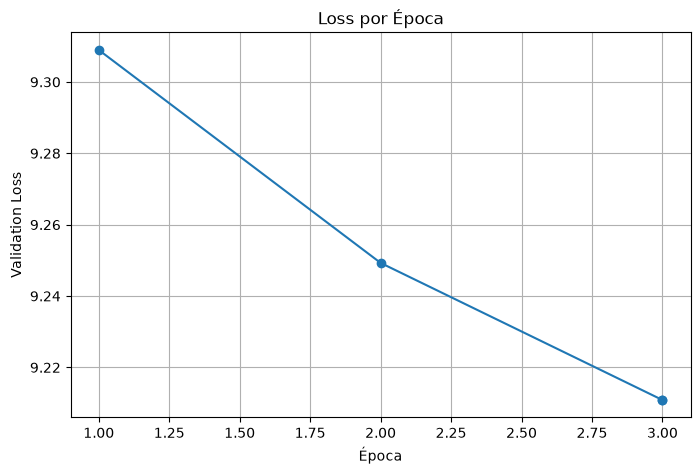

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

logs = pd.DataFrame(trainer.state.log_history)

# Apenas avaliações por época
eval_logs = logs[logs["eval_loss"].notna()]

plt.figure(figsize=(8,5))
plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="o"
)

plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.grid(True)

plt.show()

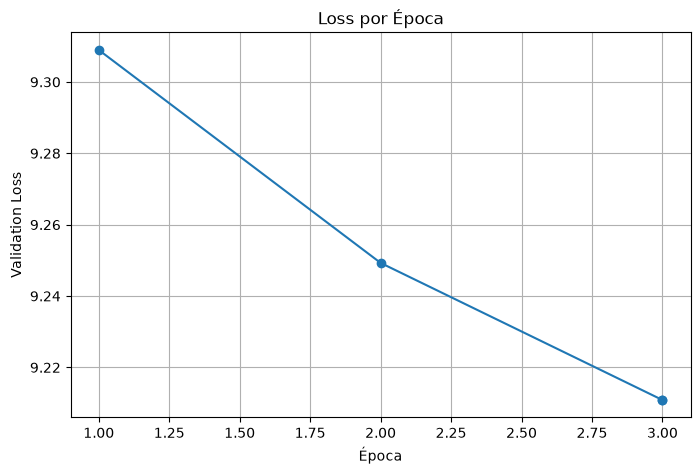

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="o"
)

plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.grid(True)

plt.savefig(
    "../reports/loss_pythia31m.png",
    bbox_inches="tight"
)

plt.show()